# Bit-Controlled Analog Output with Digilent Waveforms (pydwf)

✅ **Purpose**:  
This notebook configures the Digilent Analog Discovery (via the `pydwf` Python package) to output a DC voltage on **Wavegen Channel 1** (Analog Out) according to a provided bit string.

- For each bit in the string:
  - If the bit is `1`, output `1.0V`.
  - If the bit is `0`, output `0.0V`.
- Each output is held for exactly **1 second**.
- At the end, the output is reset to `0.0V`.

> Requires: Digilent Waveforms SDK installed and the `pydwf` package


In [1]:
import time
from pydwf import DwfLibrary, DwfAnalogOutNode, DwfAnalogOutFunction
from pydwf.utilities import openDwfDevice

# Import the function from your module
from dwf_funcs import create_figure, output_bitstream, ScanType, output_bitstream2, output_bitstream3, output_bitstream4, output_bitstream5, compute_bit_accuracy
from PIL import Image
import numpy as np

In [2]:
%matplotlib inline

In [47]:
def encode_bw_image(image: Image.Image) -> str:
    """
    Encode a black-and-white image into a bitstring.
    
    Parameters
    ----------
    image : PIL.Image.Image
        Input image. Must be in mode 'L' (grayscale) or '1' (1-bit).

    Returns
    -------
    bitstring : str
        A string of '1's and '0's, row-major flattened. '1' = black, '0' = white.
    """
    # Convert image to grayscale if not already
    if image.mode != 'L':
        image = image.convert('L')  # 8-bit pixels, black and white

    # Threshold to binary: 1 = black (pixel < 128), 0 = white (pixel ≥ 128)
    binary_array = np.array(image) < 128

    # Flatten row-major and convert to bitstring
    bitstring = ''.join(['1' if pixel else '0' for pixel in binary_array.flatten()])

    return bitstring


In [48]:
img = Image.open("creeper_10x10_bw.png")  # black & white square PNG
bitstream = encode_bw_image(img)
print(bitstream[:100])  # preview first 64 bits

0010000100011100111011111111110111001110001011010000111111000011111100111111111100110011000010000100


In [25]:
# Define your bitstream and voltage parameters
bit_string = bitstream # replace with your pattern
voltage_high = 2.0         # voltage level for LED ON
voltage_low = 0.0          # voltage level for LED OFF
hold_time = 0.1          # seconds to hold each bit
record_length_time = 10.0

In [15]:
# %%
# Create a TEST figure (time + FFT)
fig, axs = create_figure(ScanType.TEST, figsize=(6, 4))


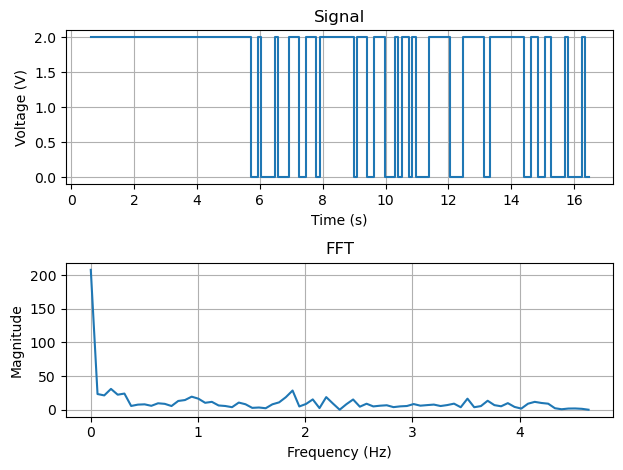

In [ ]:
fig2, axs2 = output_bitstream2(
    bit_string=bit_string,
    voltage_high=voltage_high,
    voltage_low=voltage_low,
    hold_time=hold_time,
    #record_length_time=record_length_time
)

fig2

In [104]:
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import csv
from pydwf import DwfLibrary, DwfAcquisitionMode
from pydwf.utilities import openDwfDevice


def record_scope_trace(duration_sec=10, sample_rate=10000,csv=False):
    """
    Records a scope trace using a Digilent device for a given duration.

    Returns:
    - time_array: numpy array of time points (seconds)
    - voltage_array: numpy array of voltage values (volts)
    """
    dwf = DwfLibrary()

    with openDwfDevice(dwf) as device:
        analog_in = device.analogIn

        # Configure oscilloscope
        analog_in.reset()
        analog_in.channelEnableSet(0, True)
        analog_in.channelRangeSet(0, 5.0)
        analog_in.acquisitionModeSet(DwfAcquisitionMode.Record)
        analog_in.frequencySet(sample_rate)
        analog_in.bufferSizeSet(8192)
        analog_in.recordLengthSet(duration_sec)

        analog_in.configure(reconfigure=True, start=True)
        print(f"Recording for {duration_sec} seconds...")

        total_samples = int(sample_rate * duration_sec)
        collected_data = []

        while True:
            status = analog_in.status(True)
            samples_left = analog_in.statusRecord()
            samples_available = analog_in.statusSamplesValid()
            if samples_available > 0:
                data_chunk = analog_in.statusData(0, samples_available)
                collected_data.extend(data_chunk)
            if status.name == "Done":
                break
            time.sleep(0.1)

        voltage_array = np.array(collected_data)
        time_array = np.linspace(0, duration_sec, len(voltage_array))

        # Plot
        plt.figure()
        plt.plot(time_array, voltage_array)
        plt.title("Oscilloscope Trace")
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Save to CSV
        if csv==True:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"scope_trace_{timestamp}.csv"
            with open(filename, mode='w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(["Time (s)", "Voltage (V)"])
                writer.writerows(zip(time_array, voltage_array))

            print(f"Trace saved to {filename}")

    return time_array, voltage_array


Recording for 55 seconds...


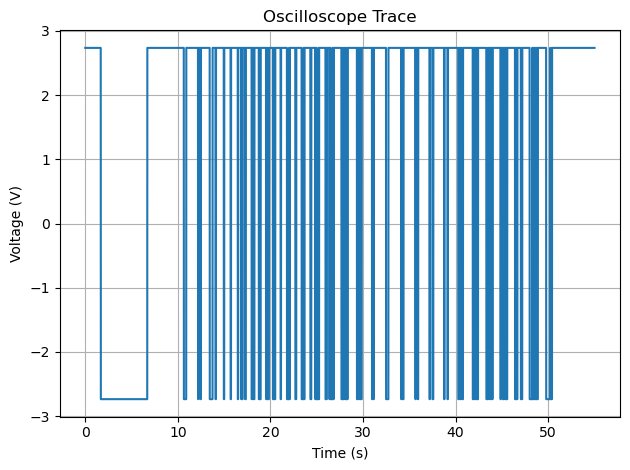

In [158]:
t, v = record_scope_trace(duration_sec=55, sample_rate=10000)

In [123]:
def decode_bitstream_from_trace(time_array, voltage_array, tbit, tbitoffset):
    """
    Decode a bitstream from the scope trace.

    Parameters:
    - time_array: array of time values (seconds)
    - voltage_array: array of voltage values (volts)
    - tbit: duration of one bit (seconds)

    Returns:
    - bitstring: a string of '0's and '1's
    """

    tbit = tbit + tbitoffset
    


    # Step 1: Detect where voltage is below 0V for at least 3 seconds
    below_zero = voltage_array < 0
    time_diff = np.diff(time_array, prepend=time_array[0])
    cumulative_below = np.cumsum(time_diff * below_zero)

    trigger_start = None
    trigger_end = None
    for i in range(len(cumulative_below)):
        if cumulative_below[i] >= 3.0:
            trigger_start = i
            break

    if trigger_start is None:
        print("No negative voltage period >3s found.")
        return ""

    for j in range(trigger_start, len(voltage_array)):
        if voltage_array[j] > 0:
            trigger_end = j
            break

    if trigger_end is None:
        print("Voltage never returned positive after negative period.")
        return ""

    # Step 2: Calculate dynamic threshold
    v_high = np.percentile(voltage_array, 90)
    v_low = np.percentile(voltage_array, 10)
    threshold = (v_high + v_low) / 2

    # Step 3: Wait tbit - tbit/2 seconds after voltage goes negative (center first bit)
    trigger_time = time_array[trigger_end] + tbit - (tbit/2)
    start_index = np.searchsorted(time_array, trigger_time)

    # Step 4: Decode bitstream
    bitstring = ""
    current_time = time_array[start_index]
    while current_time + tbit <= time_array[-1]:
        interval_start = np.searchsorted(time_array, current_time)
        interval_end = np.searchsorted(time_array, current_time + tbit)
        avg_voltage = np.mean(voltage_array[interval_start:interval_end])
        bitstring += '0' if avg_voltage > threshold else '1'
        current_time += tbit

    return bitstring


def bitstring_to_image(bitstring, N):
    """
    Converts a N^2-bit string to a 10x10 image and displays it.

    Parameters:
    - bitstring: A string of 100 bits ('0' and '1')
    """
    if len(bitstring) != N*N:
        raise ValueError("Bitstring must be exactly N^2 bits long.")

    # Convert to array of integers (0 and 1)
    bit_array = np.array([int(b) for b in bitstring])

    # Reshape to 10x10
    image_array = bit_array.reshape((N, N))

    # Display image
    plt.imshow(image_array, cmap='gray', interpolation='nearest')
    plt.title(str(N)+'x'+str(N)+" Bit Image")
    plt.axis('off')
    plt.show()



def compute_bit_accuracy(decoded, reference):
    """
    Compare decoded bitstring to reference and compute accuracy.

    Parameters:
    - decoded: the decoded bitstring (string of '0's and '1's)
    - reference: the correct reference bitstring

    Returns:
    - accuracy: fraction of matching bits (0.0 to 1.0)
    - matching: number of matching bits
    - total: number of bits compared
    """
    # Compare only up to the length of the shorter string
    min_length = min(len(decoded), len(reference))
    matches = sum(d == r for d, r in zip(decoded[:min_length], reference[:min_length]))
    accuracy = matches / min_length if min_length > 0 else 0.0

    print(f"Accuracy: {accuracy:.5%} ({matches}/{min_length} bits compared)")
    return accuracy, matches, min_length



# Creeper

Accuracy: 93.00000% (93/100 bits compared)
Accuracy: 93.00000% (93/100 bits compared)
Accuracy: 92.00000% (92/100 bits compared)
Accuracy: 90.00000% (90/100 bits compared)
Accuracy: 67.00000% (67/100 bits compared)
Accuracy: 66.00000% (66/100 bits compared)
Accuracy: 66.00000% (66/100 bits compared)
Accuracy: 66.00000% (66/100 bits compared)
Accuracy: 66.00000% (66/100 bits compared)
Accuracy: 66.00000% (66/100 bits compared)
Accuracy: 66.00000% (66/100 bits compared)
Accuracy: 66.00000% (66/100 bits compared)
Accuracy: 63.00000% (63/100 bits compared)
Accuracy: 61.00000% (61/100 bits compared)
Accuracy: 60.00000% (60/100 bits compared)
Accuracy: 59.00000% (59/100 bits compared)
Bitstring: 000000100001100111011111111111011100111000101101000011111100001111110011111111110011001100001000010000000000000000000000000000000000000000000000000000000000000000000000000000000
177


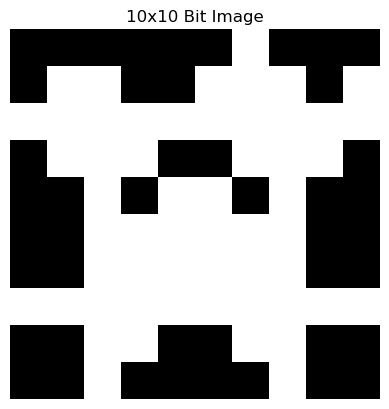

Accuracy: 93.00000% (93/100 bits compared)
 Accuracy: (0.93, 93, 100), Best Offset: 0.004


In [154]:
offsetvals = np.linspace(0.002, 0.004, 15)
creeper = np.loadtxt("encoded.txt", dtype=str)
#offset=0.0035
creeperbit_max = decode_bitstream_from_trace(t, v, 0.1, offsetvals[0])
accuracy_max = compute_bit_accuracy(creeperbit_max[:100], str(creeper))
max_off = offsetvals[0]

for off in offsetvals:
    creeperbit = decode_bitstream_from_trace(t, v, 0.1, off)
    acc = compute_bit_accuracy(creeperbit[:100], str(creeper))

    if acc >= accuracy_max:
        creeperbit_max = creeperbit
        accuracy_max = acc
        max_off = off
# 
# snoopbit = decode_bitstream_from_trace(t, v, 0.05)

# print((snoopbit))
# print(len(snoopbit))

print(f"Bitstring: {creeperbit_max}")
print(len(creeperbit_max))

bitstring_to_image(creeperbit_max[:100],10)
print(f" Accuracy: {compute_bit_accuracy(creeperbit_max[:100], str(creeper))}, Best Offset: {off}")

# Snoopy

Accuracy: 78.55556% (707/900 bits compared)
Accuracy: 78.55556% (707/900 bits compared)
Accuracy: 81.00000% (729/900 bits compared)
Accuracy: 89.44444% (805/900 bits compared)
Accuracy: 92.77778% (835/900 bits compared)
Accuracy: 82.11111% (739/900 bits compared)
Accuracy: 78.77778% (709/900 bits compared)
Accuracy: 76.55556% (689/900 bits compared)
Accuracy: 75.44444% (679/900 bits compared)
Accuracy: 74.33333% (669/900 bits compared)
Accuracy: 72.22222% (650/900 bits compared)
Accuracy: 71.00000% (639/900 bits compared)
Accuracy: 70.44444% (634/900 bits compared)
Accuracy: 70.60134% (634/898 bits compared)
Accuracy: 72.32143% (648/896 bits compared)
Accuracy: 71.58837% (640/894 bits compared)
Bitstring: 000000000000000000000000000000000000000000000000000000000000000000000000000111110000000000000000000000001000010000000000000000001111110000001000000000000000010000000000000100000000000000100000010100000110000000000010001100000000010110000000000010011100000000111010000000000010000000000

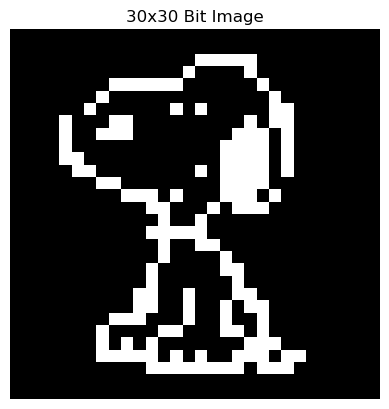

Accuracy: 92.77778% (835/900 bits compared)
 Accuracy: (0.9277777777777778, 835, 900), Best Offset: 0.004


In [159]:
offsetvals = np.linspace(0.002, 0.004, 15)
snooop = np.loadtxt("snoopy_bitstring.txt", dtype=str)

snoopbit_max = decode_bitstream_from_trace(t, v, 0.05, offsetvals[0])
accuracy_max = compute_bit_accuracy(snoopbit_max[:900], str(snooop))
max_off = offsetvals[0]

for off in offsetvals:
    snoopbit = decode_bitstream_from_trace(t, v, 0.05, off)
    acc = compute_bit_accuracy(snoopbit[:900], str(snooop))

    if acc >= accuracy_max:
        snoopbit_max = snoopbit
        accuracy_max = acc
        max_off = off


print(f"Bitstring: {snoopbit_max}")
print(len(snoopbit_max))

bitstring_to_image(snoopbit_max[:900],30)
print(f" Accuracy: {compute_bit_accuracy(snoopbit_max[:900], str(snooop))}, Best Offset: {off}")
